In [1]:
print("working")

working


In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [7]:
df = pd.read_csv("../data/students.csv")

In [8]:
df.head()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C


In [9]:
df.info

<bound method DataFrame.info of         roll_no  gender race_ethnicity parental_level_of_education  lunch  \
0        std-01    male        group D                some college    1.0   
1        std-02    male        group B                 high school    1.0   
2        std-03    male        group C             master's degree    1.0   
3        std-04    male        group D                some college    1.0   
4        std-05    male        group C                some college    0.0   
...         ...     ...            ...                         ...    ...   
9995   std-9996  female        group C                some college    1.0   
9996   std-9997  female        group C           bachelor's degree    1.0   
9997   std-9998  female        group B          associate's degree    1.0   
9998   std-9999  female        group B            some high school    1.0   
9999  std-10000  female        group B                 high school    1.0   

      test_preparation_course math_score  r

In [10]:
df.describe

<bound method NDFrame.describe of         roll_no  gender race_ethnicity parental_level_of_education  lunch  \
0        std-01    male        group D                some college    1.0   
1        std-02    male        group B                 high school    1.0   
2        std-03    male        group C             master's degree    1.0   
3        std-04    male        group D                some college    1.0   
4        std-05    male        group C                some college    0.0   
...         ...     ...            ...                         ...    ...   
9995   std-9996  female        group C                some college    1.0   
9996   std-9997  female        group C           bachelor's degree    1.0   
9997   std-9998  female        group B          associate's degree    1.0   
9998   std-9999  female        group B            some high school    1.0   
9999  std-10000  female        group B                 high school    1.0   

      test_preparation_course math_score 

In [11]:
df.shape

(10000, 12)

In [12]:
df.columns

Index(['roll_no', 'gender', 'race_ethnicity', 'parental_level_of_education',
       'lunch', 'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'total_score', 'grade'],
      dtype='str')

In [13]:
df.isnull().sum()

roll_no                         1
gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     24
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64

In [14]:
(df.isnull().sum() / len(df)) * 100

roll_no                        0.01
gender                         0.18
race_ethnicity                 0.23
parental_level_of_education    0.22
lunch                          0.24
test_preparation_course        0.23
math_score                     0.24
reading_score                  0.25
writing_score                  0.24
science_score                  0.23
total_score                    0.19
grade                          0.03
dtype: float64

In [17]:
df.dtypes

roll_no                            str
gender                             str
race_ethnicity                     str
parental_level_of_education        str
lunch                          float64
test_preparation_course        float64
math_score                         str
reading_score                  float64
writing_score                  float64
science_score                  float64
total_score                    float64
grade                              str
dtype: object

In [18]:
num_cols = ['math_score', 'reading_score', 'writing_score',
            'science_score', 'total_score']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [19]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [21]:
cat_cols = ['gender', 'race_ethnicity',
            'parental_level_of_education',
            'lunch',
            'test_preparation_course',
            'grade']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [25]:
df.isnull().sum()

roll_no                        0
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
science_score                  0
total_score                    0
grade                          0
dtype: int64

In [24]:
df['roll_no'] = df['roll_no'].fillna(0)

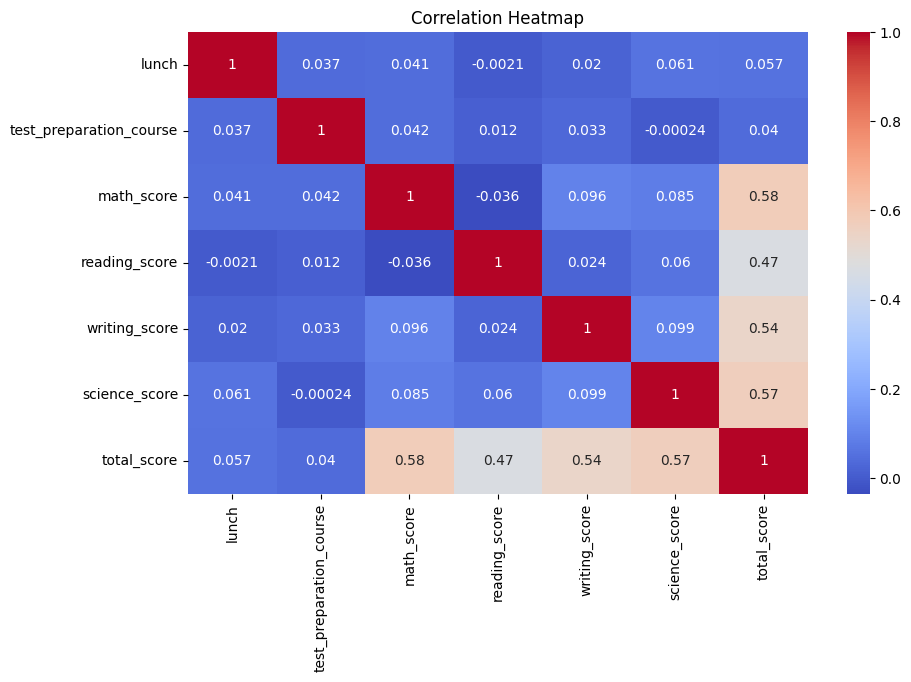

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

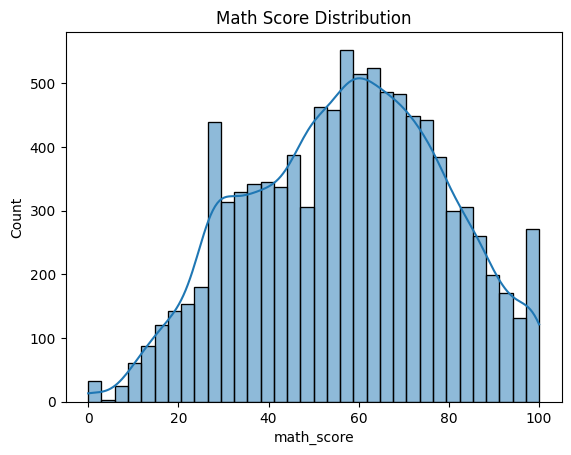

In [27]:
sns.histplot(df['math_score'], kde=True)

plt.title("Math Score Distribution")

plt.show()

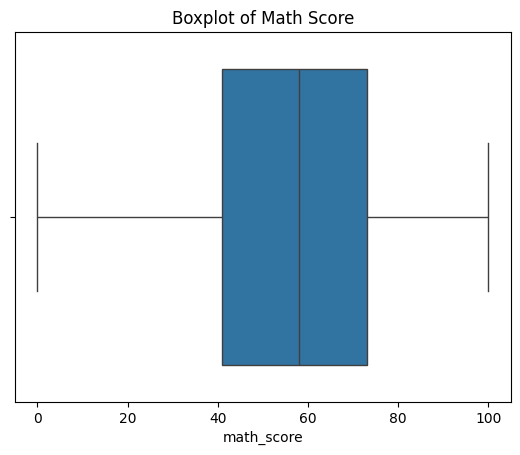

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['math_score'])

plt.title("Boxplot of Math Score")

plt.show()

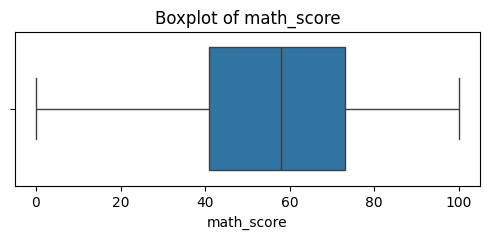

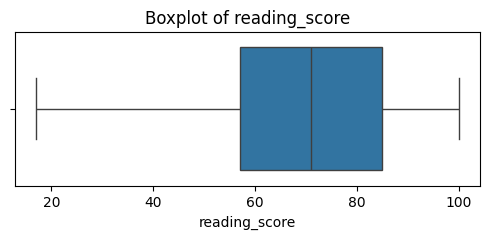

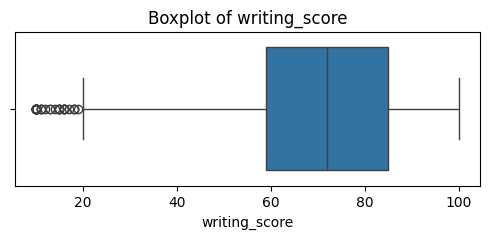

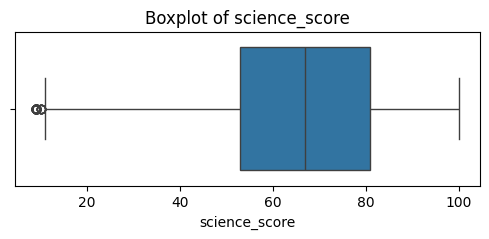

In [30]:
score_cols = ['math_score',
              'reading_score',
              'writing_score',
              'science_score']

for col in score_cols:
    
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

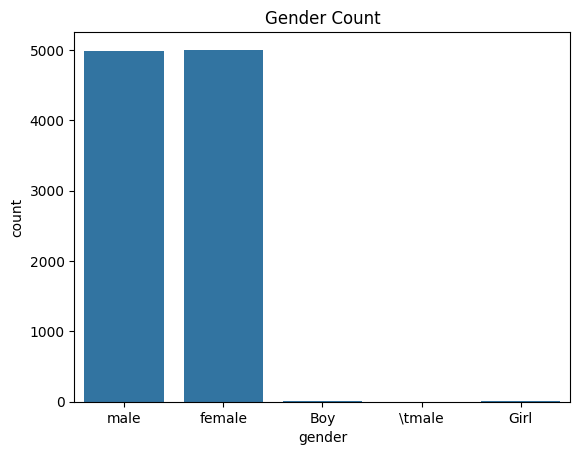

In [32]:


sns.countplot(x=df['gender'])

plt.title("Gender Count")

plt.show()

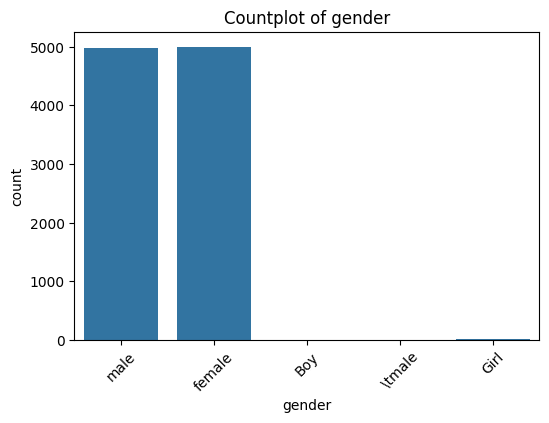

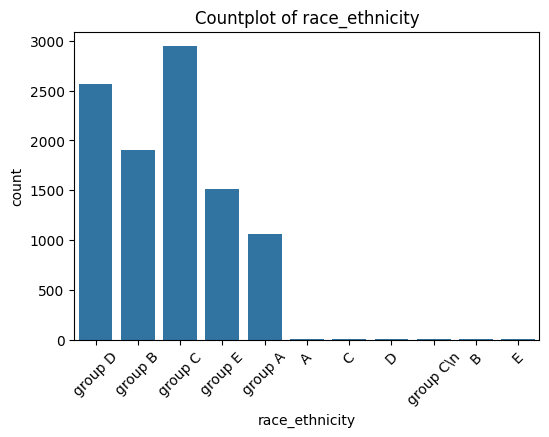

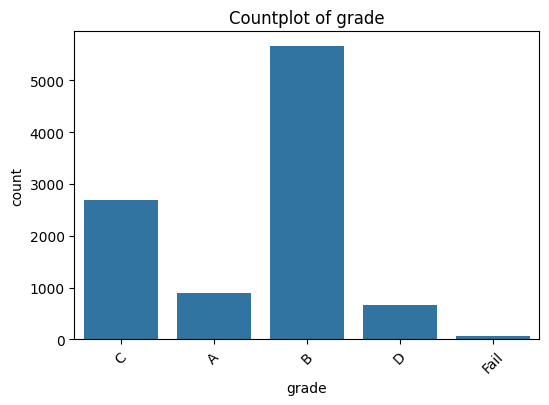

In [33]:
cat_cols = ['gender', 'race_ethnicity', 'grade']

for col in cat_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(x=df[col])
    
    plt.title(f"Countplot of {col}")
    
    plt.xticks(rotation=45)
    
    plt.show()

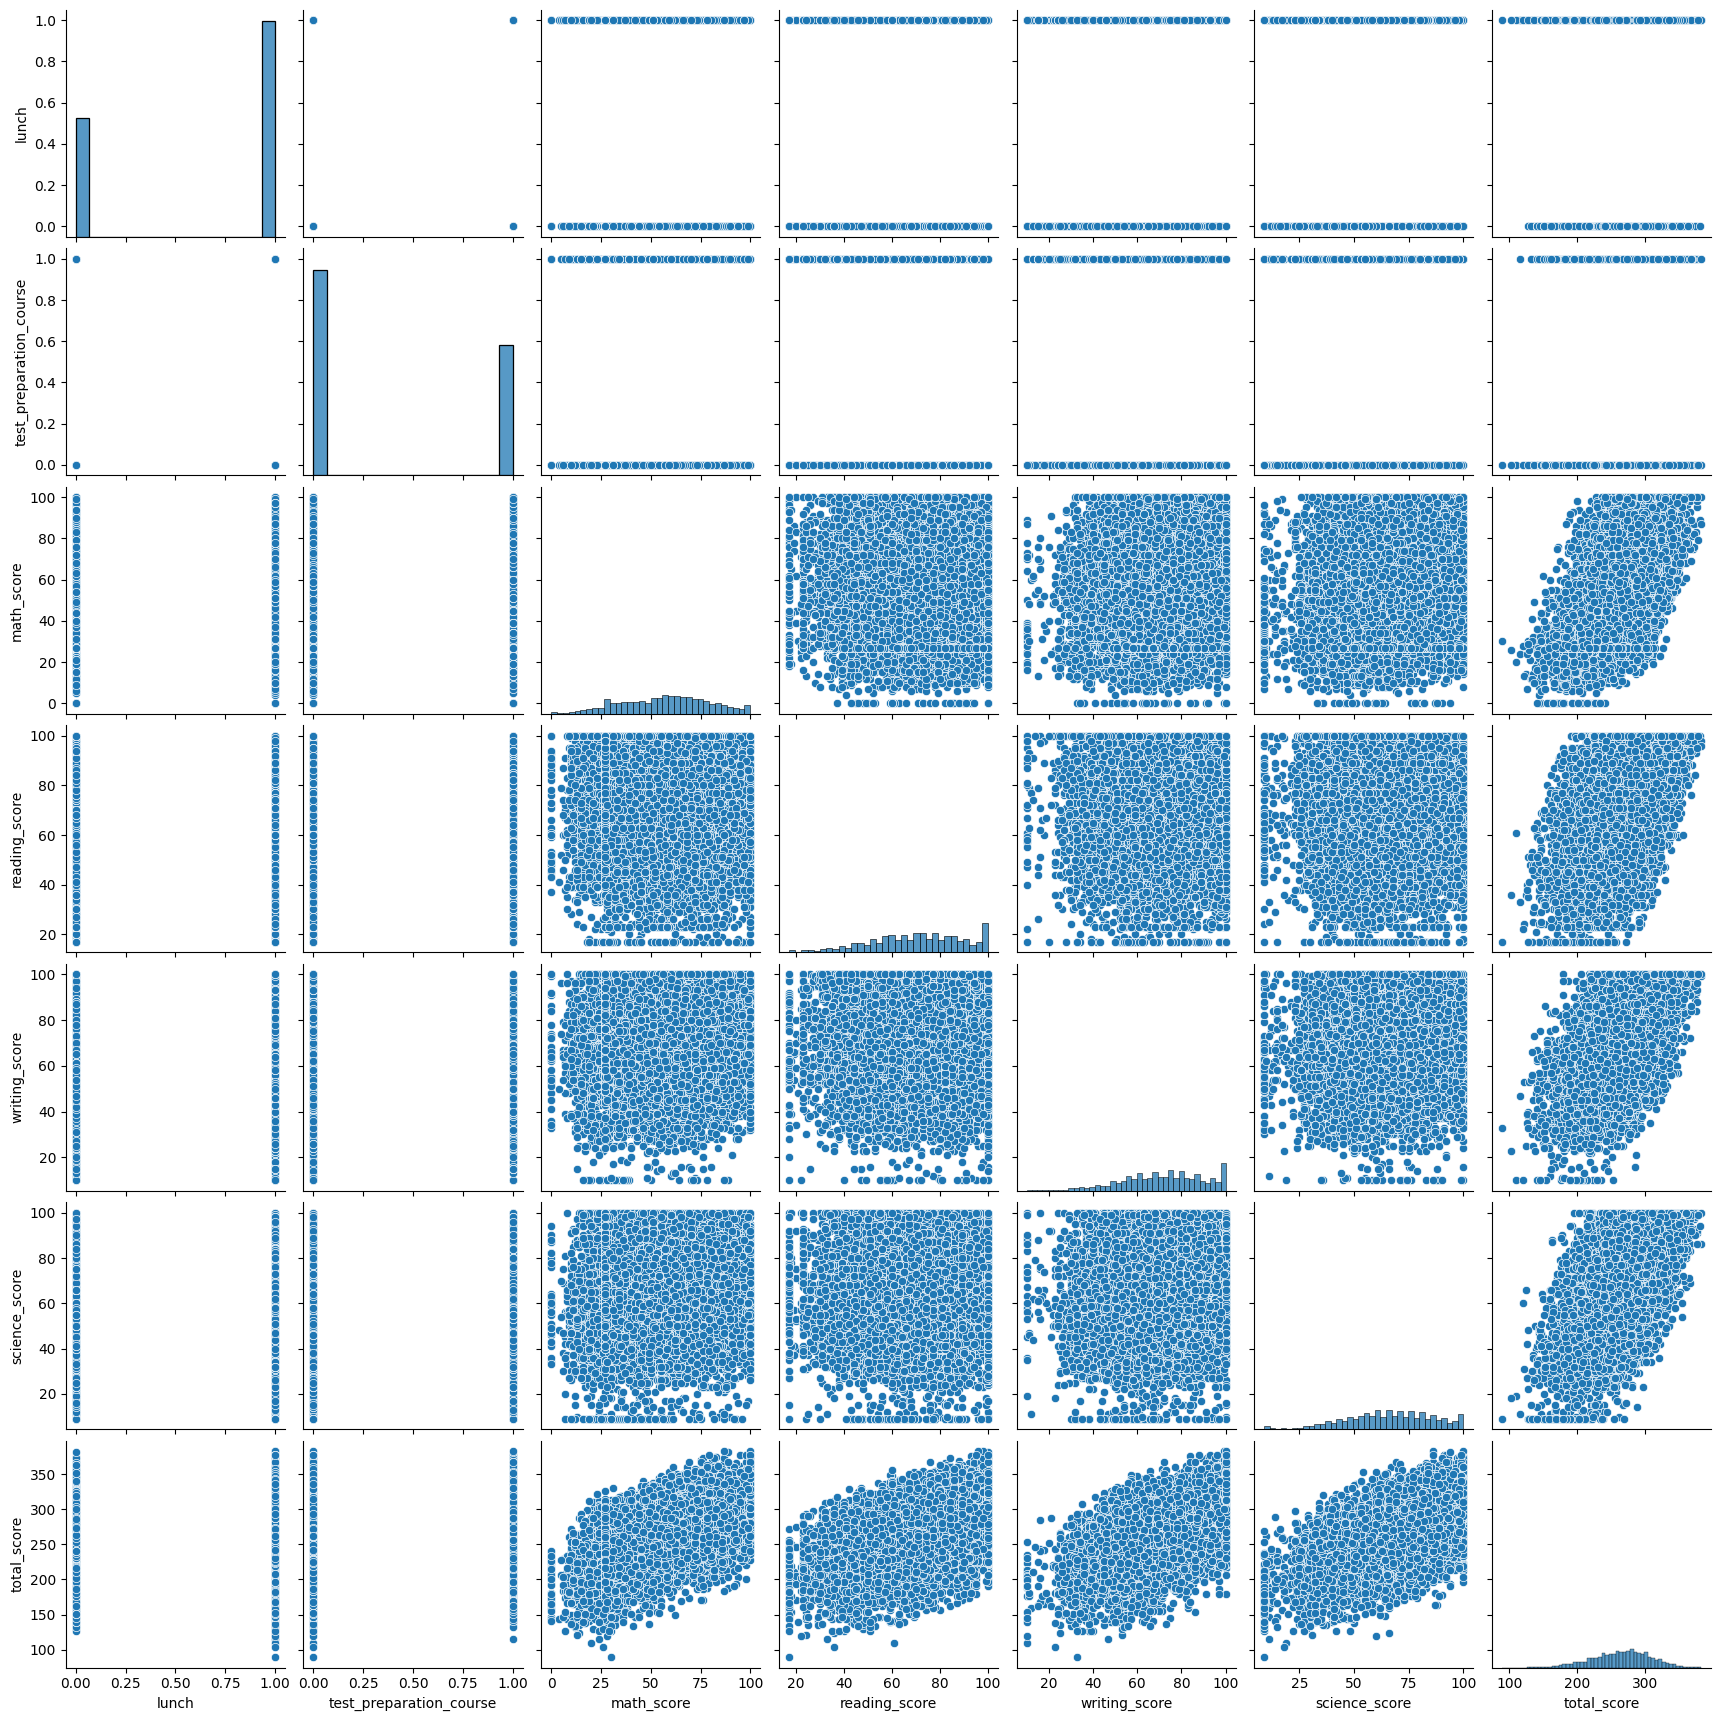

In [34]:
sns.pairplot(df)
plt.show()